In [5]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax import nnx

from dreamer.wm import DreamerConfig, DreamerWM
from dreamer.wm.losses import dreamer_wm_loss_fn

cfg = DreamerConfig()
dreamer = DreamerWM(cfg, rngs=nnx.Rngs(0))

BATCH_SIZE = 2  # num_sequences
SEQ_LENGTH = 4

from dreamer.wm.world_model import DreamerBatch

rngs = nnx.Rngs(0)
imgs = rngs.normal((BATCH_SIZE, SEQ_LENGTH, 64, 64, 3))
reward = rngs.normal((BATCH_SIZE, SEQ_LENGTH))
discount = rngs.normal((BATCH_SIZE, SEQ_LENGTH))
action = rngs.normal((BATCH_SIZE, SEQ_LENGTH, 3))
is_first = jnp.zeros((BATCH_SIZE, SEQ_LENGTH), dtype=jnp.bool)
is_first = is_first.at[:, 0].set(True)
is_first = is_first.at[:, 6].set(True)

batch = DreamerBatch(
    image=imgs, reward=reward, discount=discount, prev_action=action, is_first=is_first
)


@nnx.value_and_grad(has_aux=True)
def loss_fn(model, batch):
    losses = dreamer_wm_loss_fn(model, batch, cfg.kl_alpha)
    loss = (
        cfg.kl_beta * losses.kl_loss
        + losses.discount_loss
        + losses.reward_loss
        + losses.image_loss
    )
    return loss, losses


@nnx.jit
def train_step(model, batch, optim):
    (loss, sub_losses), grads = loss_fn(model, batch)
    optim.update(model, grads)
    return loss, sub_losses


lr = 5e-4
tx = optax.adamw(lr)
optim = nnx.Optimizer(dreamer, tx, wrt=nnx.Param)

losses = []
for i in range(200):
    loss, sub_losses = train_step(dreamer, batch, optim)
    losses.append(loss)

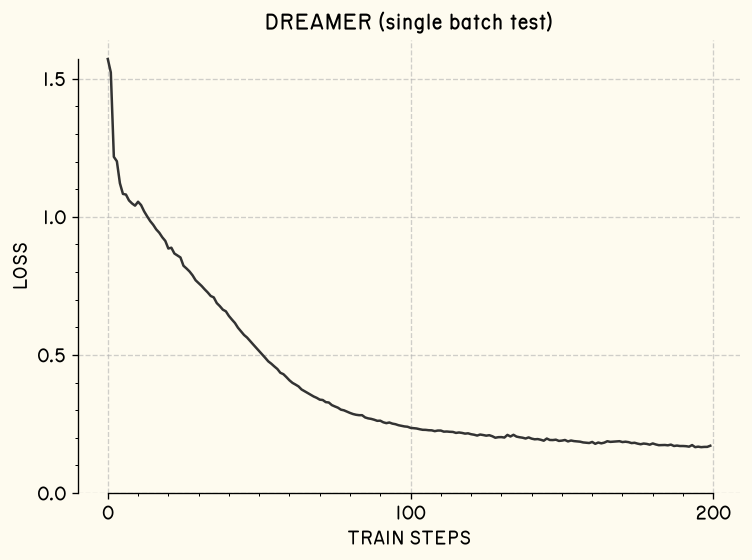

In [ ]:
blk = "#333333"
off_white = "#FEFBEF"

plt.rcParams["font.family"] = "Routed Gothic"
plt.rcParams["font.style"] = "normal"
plt.rcParams["font.size"] = 11
plt.rcParams["figure.facecolor"] = off_white
plt.rcParams["axes.facecolor"] = off_white
plt.rcParams["figure.dpi"] = 120


losses = jnp.array(losses)

fig, ax = plt.subplots()
ax.plot(losses, c=blk, linewidth=1.5)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_bounds(0, losses.max())  # type: ignore
ax.spines["bottom"].set_bounds(0, len(losses))

ax.xaxis.set_ticks(jnp.arange(0, 201, 100), minor=False)
ax.xaxis.set_ticks(jnp.arange(0, 201, 10), minor=True)


ax.yaxis.set_ticks(jnp.arange(0, losses.max() + 0.05, 0.5), minor=False)
ax.yaxis.set_ticks(jnp.arange(0, losses.max(), 0.1), minor=True)

ax.xaxis.set_label_text("TRAIN STEPS")
ax.yaxis.set_label_text("LOSS")

ax.annotate(f"{losses.min():.2f}", (500 + 6, losses.min() - 0.045))

ax.set_title(
    "DREAMER (single batch test)",
    fontstyle="italic",
    fontfeatures=["ss01[0]"],
)

plt.grid(alpha=0.6, linestyle="--")
plt.tight_layout()
plt.savefig("../../assets/dummy_batch.png", dpi=300)
plt.show()